# Was grandma right? Is it really the phone?

The full dataset was retrieved from [kaggle.com](https://www.kaggle.com/datasets/souvikahmed071/social-media-and-mental-health).


## Setup

Import libraries, load data and customisation of columns.

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv('../data/smmh.csv')
data.head()

,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


Group the Gender column

In [5]:
data['Gender_Grouped'] = data['2. Gender'].replace({
    'Nonbinary ': 'Non-binary',
    'Non-binary': 'Non-binary',
    'NB': 'Non-binary',
    'Non binary ': 'Non-binary',
    'Male': 'Male',
    'Female': 'Female',
    'unsure ': 'Other',
    'Trans': 'Other',
    'There are others???': 'Other'
})
print(data['Gender_Grouped'].unique())

<StringArray>
['Male', 'Female', 'Non-binary', 'Other']
Length: 4, dtype: str


# Introduction
To introduce our data to the user we decided to present the cohort in simple pie charts. First the focus is on how many people actually use social media, what kind is the most popular and how long do the users spend there daily. Pie charts are a great option here as they are easily readable and get a good first idea of data.
Next, we show bar chart with counts of cohort's occupation, and grouped marital status and gender, (maybe should group age by accupation)
The summary of the questions that they were asked can also be looked at before the user dives deeper in the analysis.

In [ ]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import numpy as np
from scipy.stats import gaussian_kde
import json, re

# data
data = pd.read_csv('../data/smmh.csv')

First we group gender column and rename the questions for easier handling.

In [ ]:
# ── 0. Gender normalisation ──────────────────────────────────────────────────
data['Gender_Grouped'] = data['2. Gender'].replace({
    'Nonbinary ':          'Non-binary',
    'Non-binary':          'Non-binary',
    'NB':                  'Non-binary',
    'Non binary ':         'Non-binary',
    'Male':                'Male',
    'Female':              'Female',
    'unsure ':             'Other',
    'Trans':               'Other',
    'There are others???': 'Other',
})

# ── 1. Column rename ─────────────────────────────────────────────────────────
SHORT = {
    "1. What is your age?":                                    "age",
    "Gender_Grouped":                                          "gender",
    "3. Relationship Status":                                  "relationship",
    "4. Occupation Status":                                    "occupation",
    "5. What type of organizations are you affiliated with?":  "org",
    "6. Do you use social media?":                             "uses_sm",
    "7. What social media platforms do you commonly use?":     "platforms",
    "8. What is the average time you spend on social media every day?": "daily_time",
    "9. How often do you find yourself using Social media without a specific purpose?":  "q9",
    "10. How often do you get distracted by Social media when you are busy doing something?": "q10",
    "11. Do you feel restless if you haven't used Social media in a while?":             "q11",
    "12. On a scale of 1 to 5, how easily distracted are you?":                         "q12",
    "13. On a scale of 1 to 5, how much are you bothered by worries?":                  "q13",
    "14. Do you find it difficult to concentrate on things?":                            "q14",
    "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?": "q15",
    "16. Following the previous question, how do you feel about these comparisons, generally speaking?": "q16",
    "17. How often do you look to seek validation from features of social media?":       "q17",
    "18. How often do you feel depressed or down?":                                      "q18",
    "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?": "q19",
    "20. On a scale of 1 to 5, how often do you face issues regarding sleep?":           "q20",
}
df = data.rename(columns={k: v for k, v in SHORT.items() if k in data.columns})

We present the basic statisctics in interactive manner. For further analysis we excluded the three non-users as despite saying "no" when asked if they use social media, they replied to the rest of the questionaire.

In [ ]:
# Display all columns for non-users
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
print("All data for non-users:")
print(non_users.to_string())

In [ ]:
out = {}

# ── 2. Top-level stats ───────────────────────────────────────────────────────
out["total"]    = int(len(df))
out["users"]    = int((df["uses_sm"] == "Yes").sum())  if "uses_sm" in df.columns else None
out["nonUsers"] = int((df["uses_sm"] == "No").sum())   if "uses_sm" in df.columns else None
out["avgAge"]   = round(float(df["age"].dropna().mean()), 1) if "age" in df.columns else None

# ── 3. Users vs Non-users pie ────────────────────────────────────────────────
if "uses_sm" in df.columns:
    vc = df["uses_sm"].value_counts()
    out["usersPie"] = [{"name": k, "value": int(v)} for k, v in vc.items()]

# ── 4. Platforms pie ─────────────────────────────────────────────────────────
PLATFORM_LIST = [
    "YouTube","Instagram","Facebook","Twitter","TikTok",
    "Snapchat","Discord","Pinterest","Reddit","LinkedIn",
]
if "platforms" in df.columns:
    counts_p = {}
    for p in PLATFORM_LIST:
        n = int(df["platforms"].dropna().str.contains(p, case=False, na=False).sum())
        if n: counts_p[p] = n
    out["platforms"] = sorted(
        [{"name": k, "value": v} for k, v in counts_p.items()],
        key=lambda x: -x["value"]
    )

# ── 5. Age distribution bars ─────────────────────────────────────────────────
if "age" in df.columns:
    ages = df["age"].dropna()

    def age_label(a):
        if a < 15:  return "<15"
        if a <= 30: return str(int(a))
        if a <= 40: return "31-40"
        return "40+"

    age_series = ages.apply(age_label)
    order = [str(i) for i in range(15, 31)] + ["31-40", "40+", "<15"]
    vc = age_series.value_counts()
    out["ageBins"] = [
        {"label": lbl, "n": int(vc.get(lbl, 0))}
        for lbl in order if vc.get(lbl, 0) > 0
    ]

# ── 6. Gender × Relationship ─────────────────────────────────────────────────
if "gender" in df.columns and "relationship" in df.columns:
    preferred_rel = ["Single", "In a relationship", "Married", "Divorced"]
    cross = df.groupby(["relationship", "gender"]).size().unstack(fill_value=0)
    rel_order = [r for r in preferred_rel if r in cross.index] + \
                [r for r in cross.index  if r not in preferred_rel]
    cross = cross.reindex(rel_order)

    out["relationship"] = []
    for rel in rel_order:
        row = {"status": rel, "total": int(cross.loc[rel].sum()), "breakdown": {}}
        for g in cross.columns:
            row["breakdown"][g] = int(cross.loc[rel, g])
        out["relationship"].append(row)

    out["genders"] = list(cross.columns)

# ── 7. Occupation ─────────────────────────────────────────────────────────────
if "occupation" in df.columns:
    vc = df["occupation"].value_counts()
    out["occupation"] = [{"label": k, "n": int(v)} for k, v in vc.items()]

# ── 8. Daily screen time ─────────────────────────────────────────────────────
TIME_ORDER = [
    "Less than an Hour","Between 1 and 2 hours","Between 2 and 3 hours",
    "Between 3 and 4 hours","Between 4 and 5 hours","More than 5 hours",
]
if "daily_time" in df.columns:
    vc = df["daily_time"].value_counts()
    out["dailyTime"] = [
        {"label": lbl, "n": int(vc.get(lbl, 0))}
        for lbl in TIME_ORDER if vc.get(lbl, 0) > 0
    ]

# ── 9. Mental health averages ─────────────────────────────────────────────────
MH_COLS = ["q9","q10","q11","q12","q13","q14","q15","q17","q18","q19","q20"]
mh_avgs = {}
for col in MH_COLS:
    if col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        mh_avgs[col] = round(float(numeric.mean()), 2) if numeric.notna().any() else None
out["mhAverages"] = mh_avgs



✓ Exported 13 sections → survey_data.json
  Total respondents : 481
  SM users          : 478 (99.4%)
  Avg age           : 26.1
  Relationship rows : 4
  Platform rows     : 9
  Age bins          : 19


Exporting JSON

In [ ]:
# ── 10. Write JSON ────────────────────────────────────────────────────────────
OUTPUT_PATH = "survey_data.json"

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2, ensure_ascii=False)

print(f"✓ Exported {len(out)} sections → {OUTPUT_PATH}")
print(f"  Total respondents : {out['total']}")
print(f"  SM users          : {out['users']} ({out['users']/out['total']*100:.1f}%)")
print(f"  Avg age           : {out['avgAge']}")
print(f"  Relationship rows : {len(out.get('relationship', []))}")
print(f"  Platform rows     : {len(out.get('platforms', []))}")
print(f"  Age bins          : {len(out.get('ageBins', []))}")

# Each app and the associated stereotype

We wanted to find out if the stereotypes are true. We grouped questions that have influence on particular stereotypes that are being told about 
particular apps.


In [ ]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import numpy as np
from scipy.stats import gaussian_kde
import json, re

# data
data = pd.read_csv('../data/smmh.csv')

Renaming the columns and getting the mean values for each question

In [ ]:
# -----------------------------
# COLUMN DEFINITIONS
# -----------------------------
question_cols = {
    9: "9. How often do you find yourself using Social media without a specific purpose?",
    10: "10. How often do you get distracted by Social media when you are busy doing something?",
    11: "11. Do you feel restless if you haven't used Social media in a while?",
    12: "12. On a scale of 1 to 5, how easily distracted are you?",
    13: "13. On a scale of 1 to 5, how much are you bothered by worries?",
    14: "14. Do you find it difficult to concentrate on things?",
    15: "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?",
    16: "16. Following the previous question, how do you feel about these comparisons, generally speaking?",
    17: "17. How often do you look to seek validation from features of social media?",
    18: "18. How often do you feel depressed or down?",
    19: "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?",
    20: "20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
}

platform_col = "7. What social media platforms do you commonly use?"

# -----------------------------
# CREATE PLATFORM TABLE
# -----------------------------
platforms = [
    "Instagram",
    "Facebook",
    "Twitter",
    "YouTube",
    "Discord",
    "Pinterest",
    "TikTok",
    "Snapchat",
    "Reddit",
    "LinkedIn"
]

results = []

for platform in platforms:

    subset = data[
        data[platform_col]
        .fillna("")
        .str.contains(platform, case=False)
    ]

    if len(subset) == 0:
        continue

    row = {
        "Platform": platform,
        "Users": len(subset),
        "Average Age": subset["1. What is your age?"].mean(),
    }

    # Mean scores for Q9-Q20
    for q_num, q_col in question_cols.items():
        row[f"Q{q_num}"] = pd.to_numeric(
            subset[q_col],
            errors="coerce"
        ).mean()

    results.append(row)

platform_scores = pd.DataFrame(results)

# -----------------------------
# PRINT SUMMARY
# -----------------------------
print(platform_scores.round(2))

    Platform  Users  Average Age    Q9   Q10   Q11   Q12   Q13   Q14   Q15  \
0  Instagram    359        24.37  3.64  3.48  2.67  3.48  3.75  3.39  2.93   
1   Facebook    407        26.15  3.58  3.40  2.64  3.36  3.61  3.28  2.92   
2    Twitter    131        26.89  3.54  3.18  2.55  3.34  3.68  3.16  2.66   
3    YouTube    412        25.87  3.59  3.34  2.59  3.35  3.60  3.24  2.85   
4    Discord    198        22.81  3.67  3.43  2.55  3.48  3.75  3.40  2.79   
5  Pinterest    145        24.57  3.62  3.36  2.57  3.35  3.72  3.17  2.85   
6     TikTok     94        23.67  3.84  3.78  3.02  3.80  4.03  3.66  3.40   
7   Snapchat    181        22.76  3.72  3.60  2.78  3.61  3.84  3.51  3.04   
8     Reddit    126        23.56  3.68  3.20  2.38  3.43  3.73  3.30  2.60   

    Q16   Q17   Q18   Q19   Q20  
0  2.75  2.54  3.40  3.28  3.30  
1  2.74  2.53  3.31  3.17  3.25  
2  2.75  2.31  3.25  2.97  3.21  
3  2.78  2.46  3.28  3.18  3.22  
4  2.85  2.38  3.41  3.18  3.40  
5  2.79  2.50  

Heatmap allow us to see the scores for each question and each platform. We can easily read which questions are the most concerning - have the highest scores across all types of social media (Q9 How often do you find yourself using Social media without a specific purpose? and Q13 On a scale of 1 to 5, how much are you bothered by worries?) and which platform has generally elevated scores - TikTok. 
For the website we chose to represent this data in a word map where the bigger is the name of the platform the higher it scored in the question. 

In [ ]:
# -----------------------------
# HEATMAP VISUALIZATION
# -----------------------------
score_cols = [f"Q{i}" for i in range(9, 21)]

heatmap_data = platform_scores.set_index("Platform")[score_cols]

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(heatmap_data, aspect='auto')

# Axis labels
ax.set_xticks(np.arange(len(score_cols)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(score_cols)
ax.set_yticklabels(heatmap_data.index)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Add values inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(score_cols)):
        value = heatmap_data.iloc[i, j]
        ax.text(j, i, f"{value:.1f}",
                ha="center",
                va="center")

ax.set_title("Average scores by platform (Q9-Q20)")

fig.colorbar(im)

plt.tight_layout()
plt.show()



NameError: name 'platform_scores' is not defined

After seeing the heatmap, we suspect that TikTok, despite the low ammount of users in this cohort, is associated with many negative effects on mental health. 
For the website we chose to represent this data in a word map where the bigger is the name of the platform the higher it scored in the question. For further analysis we exclude this app to see more telling data.

   Question Most Associated Platform(s)  Average Score
0        Q9                           i           3.60
1       Q10                        k, k           3.39
2       Q11                        k, k           2.65
3       Q12                           i           3.43
4       Q13                           i           3.67
5       Q14                           i           3.32
6       Q15                        k, k           2.93
7       Q16                           o           2.77
8       Q17                        k, k           2.53
9       Q18                           i           3.35
10      Q19                           i           3.23
11      Q20                        k, k           3.26


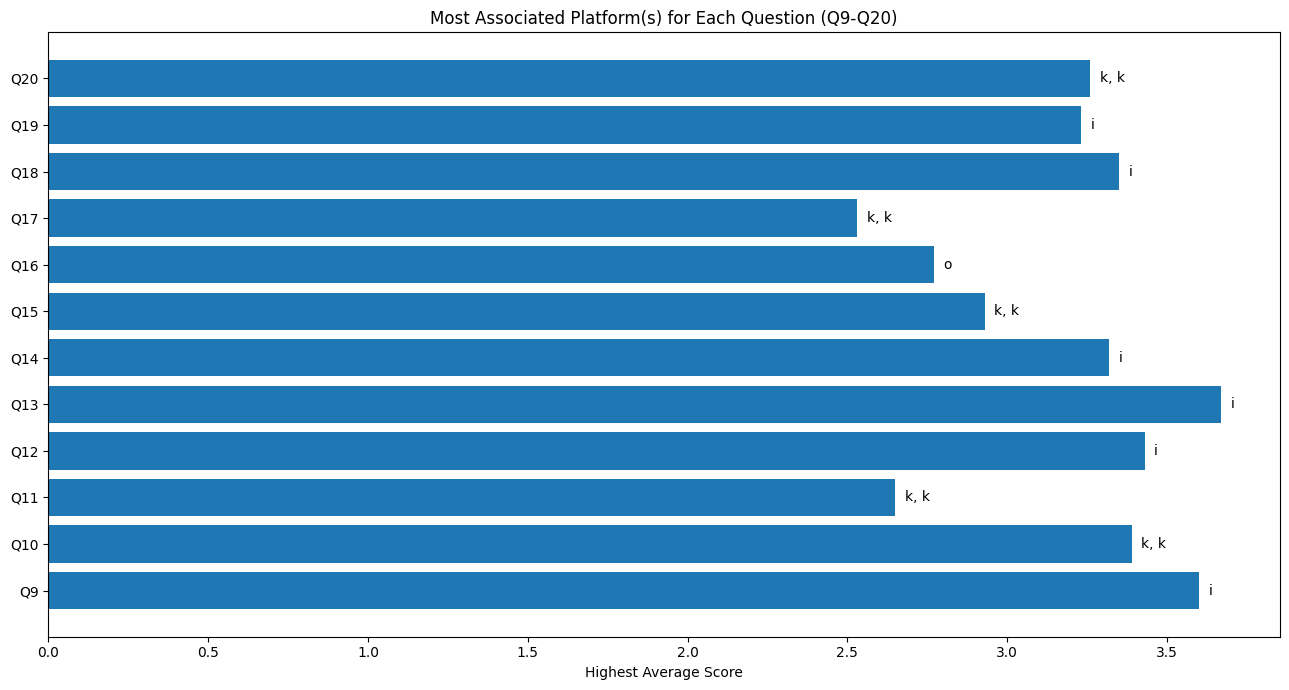

In [ ]:
# -----------------------------
# CALCULATE PLATFORM MEANS
# -----------------------------
results = []

for platform in platforms:

    subset = data[
        data[platform_col]
        .fillna("")
        .str.contains(platform, case=False)
    ]

    if len(subset) == 0:
        continue

    row = {"Platform": platform}

    for q_num, q_col in question_cols.items():

        row[f"Q{q_num}"] = pd.to_numeric(
            subset[q_col],
            errors="coerce"
        ).mean()

    results.append(row)

scores_data = pd.DataFrame(results)

# -----------------------------
# FIND MOST ASSOCIATED PLATFORM(S)
# includes ties
# -----------------------------
summary_rows = []

for q_num in range(9, 21):

    q_col = f"Q{q_num}"

    max_score = scores_data[q_col].max()

    best_platforms = scores_data.loc[
        scores_data[q_col] == max_score,
        "Platform"
    ].tolist()

    summary_rows.append({
        "Question": q_col,
        "Most Associated Platform(s)": ", ".join(best_platforms),
        "Average Score": round(max_score, 2)
    })

summary_data = pd.DataFrame(summary_rows)

print(summary_data)

# -----------------------------
# VISUALIZATION WITH TIES
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    summary_data["Question"],
    summary_data["Average Score"]
)

for i, bar in enumerate(bars):

    platforms = summary_data.iloc[i]["Most Associated Platform(s)"]

    ax.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height() / 2,
        platforms,
        va="center"
    )

ax.set_xlabel("Highest Average Score")
ax.set_title("Most Associated Platform(s) for Each Question (Q9-Q20)")

plt.tight_layout()
plt.show()

# People & platform profile page generator

First we analyse the subgroup of people using TikTok alone or in combination with other apps. These people are ususally single university students and alaso use Instagram as their second choice.

- How old users are, their affiliations, occupations, and relationship status
- Which apps are popular among people aged 60+
- Which apps are common among people spending **less than 1 hour/day** on social media
- Outliers: respondents with extremely high mental-health scores, the youngest respondent(s), and the oldest respondent(s)
- How non-users score across the mental-health questions, shown as a **small-n descriptive analysis** so it is not overinterpreted


In [ ]:
import pandas as pd
import json
from pathlib import Path

# -----------------------------
# INPUT / OUTPUT
# -----------------------------
csv_file = "../data/smmh.csv"
out_html = "../html-files/others.html"

Path(out_html).parent.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(csv_file)

# -----------------------------
# COLUMN DEFINITIONS
# -----------------------------
age_col = "1. What is your age?"
gender_col = "2. Gender"
relationship_col = "3. Relationship Status"
occupation_col = "4. Occupation Status"
affiliation_col = "5. What type of organizations are you affiliated with?"
use_col = "6. Do you use social media?"
platform_col = "7. What social media platforms do you commonly use?"
time_col = "8. What is the average time you spend on social media every day?"

question_cols = {
    "Q9": "9. How often do you find yourself using Social media without a specific purpose?",
    "Q10": "10. How often do you get distracted by Social media when you are busy doing something?",
    "Q11": "11. Do you feel restless if you haven't used Social media in a while?",
    "Q12": "12. On a scale of 1 to 5, how easily distracted are you?",
    "Q13": "13. On a scale of 1 to 5, how much are you bothered by worries?",
    "Q14": "14. Do you find it difficult to concentrate on things?",
    "Q15": "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?",
    "Q16": "16. Following the previous question, how do you feel about these comparisons, generally speaking?",
    "Q17": "17. How often do you look to seek validation from features of social media?",
    "Q18": "18. How often do you feel depressed or down?",
    "Q19": "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?",
    "Q20": "20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
}

question_labels = {
    "Q9": "Purposeless use",
    "Q10": "Distracted while busy",
    "Q11": "Restless offline",
    "Q12": "Easily distracted",
    "Q13": "Bothered by worries",
    "Q14": "Concentration issues",
    "Q15": "Social comparison",
    "Q16": "Feeling after comparison",
    "Q17": "Validation seeking",
    "Q18": "Feeling down",
    "Q19": "Interest fluctuation",
    "Q20": "Sleep issues"
}

platforms = [
    "Instagram", "Facebook", "Twitter", "YouTube", "Discord",
    "Pinterest", "TikTok", "Snapchat", "Reddit", "LinkedIn"
]

# -----------------------------
# CLEANING HELPERS
# -----------------------------
df[age_col] = pd.to_numeric(df[age_col], errors="coerce")

for _, col in question_cols.items():
    df[col] = pd.to_numeric(df[col], errors="coerce")

def has_platform(series, platform):
    return series.fillna("").str.contains(platform, case=False, regex=False)

def value_counts_payload(series, top_n=None):
    vc = series.fillna("Unknown").value_counts()
    if top_n:
        vc = vc.head(top_n)

    total = int(vc.sum()) if int(vc.sum()) else 1

    return [
        {
            "label": str(k),
            "n": int(v),
            "pct": round(v / total * 100, 1)
        }
        for k, v in vc.items()
    ]

def multi_platform_counts(data):
    rows = []

    for p in platforms:
        n = int(has_platform(data[platform_col], p).sum())

        if n > 0:
            rows.append({
                "platform": p,
                "n": n,
                "pct": round(n / max(len(data), 1) * 100, 1)
            })

    return sorted(rows, key=lambda x: x["n"], reverse=True)

def time_sort_key(label):
    order = {
        "Less than an Hour": 0,
        "Less than an hour": 0,
        "Between 1 and 2 hours": 1,
        "Between 2 and 3 hours": 2,
        "Between 3 and 4 hours": 3,
        "Between 4 and 5 hours": 4,
        "More than 5 hours": 5,
    }
    return order.get(str(label), 99)

# -----------------------------
# TIKTOK USERS ONLY
# -----------------------------
tiktok_users = df[has_platform(df[platform_col], "TikTok")].copy()

tiktok_other_apps = []

for app in platforms:
    if app == "TikTok":
        continue

    n = int(has_platform(tiktok_users[platform_col], app).sum())
    pct = round(n / max(len(tiktok_users), 1) * 100, 1)

    tiktok_other_apps.append({
        "label": app,
        "platform": app,
        "n": n,
        "pct": pct
    })

tiktok_other_apps = sorted(tiktok_other_apps, key=lambda x: x["n"], reverse=True)

tiktok_payload = {
    "n": int(len(tiktok_users)),
    "ageMean": round(tiktok_users[age_col].mean(), 1) if len(tiktok_users) else None,
    "occupation": value_counts_payload(tiktok_users[occupation_col]),
    "relationship": value_counts_payload(tiktok_users[relationship_col]),
    "otherApps": tiktok_other_apps
}

For the second section, we chose to look at where do light scrollers - people that spend less than an hour online - spend their time.
These users usually fall in the category male 45 - 59 years old and is a salaried worker.
Facebook dominates this subgroup, and TikTok in this demographic falls to the last place with only two users. 


In [ ]:
# -----------------------------
# LIGHT USERS
# -----------------------------
light_users = df[
    df[time_col]
    .fillna("")
    .str.contains("Less than", case=False, regex=False)
].copy()

age_bins = [0, 17, 24, 34, 44, 59, 200]
age_labels = ["≤17", "18–24", "25–34", "35–44", "45–59", "60+"]

light_users["age_bin"] = pd.cut(
    light_users[age_col],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

light_age_dist = light_users["age_bin"].value_counts().reindex(age_labels, fill_value=0)

light_age_payload = [
    {"ageGroup": str(k), "n": int(v)}
    for k, v in light_age_dist.items()
]

light_gender_payload = value_counts_payload(light_users[gender_col])
light_occupation_payload = value_counts_payload(light_users[occupation_col])
light_app_payload = multi_platform_counts(light_users)


Our last subgroup is people aged 60 and above. We only have 4 respondents in this category. The most popular apps are Facebook and Youtube, and all of the users spend more that an hour online. We chose to keep the same visualisations - bar charts, so the user can easily follow the page. 

In [ ]:
# -----------------------------
# 60+ USERS
# -----------------------------
older = df[df[age_col] >= 60].copy()

older_time = (
    older[time_col]
    .fillna("Unknown")
    .value_counts()
    .sort_index(key=lambda idx: [time_sort_key(x) for x in idx])
)

older_payload = {
    "n": int(len(older)),
    "ageMean": round(older[age_col].mean(), 1) if len(older) else None,
    "ageMin": int(older[age_col].min()) if len(older) else None,
    "ageMax": int(older[age_col].max()) if len(older) else None,
    "apps": multi_platform_counts(older),
    "time": [
        {
            "label": str(k),
            "n": int(v),
            "pct": round(v / max(len(older), 1) * 100, 1)
        }
        for k, v in older_time.items()
    ]
}


Lastly, we want to see if there are people with severe scores on the mental health scales. We calculate the average scores for questions 9 to 20 and pull those who's score is 5. This dataset has five respondents with 5/5 average. We include all information and display it in a card format to avoid misleading conclusions, so that the users can interpret it themselves.

Additionally, we display the youngest and the oldest respondent in the same manner.

In [ ]:
# -----------------------------
# SECTION 5: OUTLIERS / EXTREMES
# -----------------------------
score_cols = list(question_cols.values())

df["mean_mh_score"] = df[score_cols].mean(axis=1)
df["n_5_scores"] = (df[score_cols] == 5).sum(axis=1)

perfect = df[df["mean_mh_score"] == 5].copy()

perfect_rows = []

for idx, row in perfect.iterrows():
    perfect_rows.append({
        "row": int(idx),
        "age": None if pd.isna(row[age_col]) else float(row[age_col]),
        "gender": str(row.get(gender_col, "Unknown")),
        "occupation": str(row.get(occupation_col, "Unknown")),
        "relationship": str(row.get(relationship_col, "Unknown")),
        "platforms": str(row.get(platform_col, "")),
        "time": str(row.get(time_col, "")),
        "meanScore": round(float(row["mean_mh_score"]), 2),
        "nFive": int(row["n_5_scores"])
    })

age_valid = df[df[age_col].notna()].copy()

youngest = age_valid.loc[age_valid[age_col].idxmin()]
oldest = age_valid.loc[age_valid[age_col].idxmax()]

def person_payload(row):
    return {
        "row": int(row.name),
        "age": float(row[age_col]),
        "gender": str(row.get(gender_col, "Unknown")),
        "occupation": str(row.get(occupation_col, "Unknown")),
        "relationship": str(row.get(relationship_col, "Unknown")),
        "affiliation": str(row.get(affiliation_col, "Unknown")),
        "usesSocial": str(row.get(use_col, "Unknown")),
        "platforms": str(row.get(platform_col, "")),
        "time": str(row.get(time_col, "")),
        "meanScore": round(float(row[score_cols].mean()), 2) if row[score_cols].notna().any() else None
    }

outlier_payload = {
    "perfectScorePeople": perfect_rows,
    "perfectCount": int(len(perfect_rows)),
    "youngest": person_payload(youngest),
    "oldest": person_payload(oldest)
}


Saved HTML to: ../html-files/others.html


Writing html

In [16]:

# -----------------------------
# FINAL PAYLOAD
# -----------------------------
payload = {
    "tiktok": tiktok_payload,
    "lightUsers": {
        "n": int(len(light_users)),
        "ageDistribution": light_age_payload,
        "genderDistribution": light_gender_payload,
        "occupationDistribution": light_occupation_payload,
        "apps": light_app_payload
    },
    "older60": older_payload,
    "outliers": outlier_payload,
    "nonUsers": non_user_payload
}

DATA_JSON = json.dumps(payload, indent=2)

# -----------------------------
# HTML TEMPLATE
# -----------------------------
html = r'''
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Who Are Extremes?</title>
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,400;0,700;0,900;1,400;1,700&family=DM+Mono:wght@300;400;500&family=DM+Sans:wght@300;400;500&display=swap" rel="stylesheet">

<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js"></script>

<style>
:root {
  --cream:#F5F0E8;
  --dark:#1A1209;
  --warm:#C8A96E;
  --accent:#E8472A;
  --muted:#6B5E4A;
  --card:#FFFDF7;
  --border:rgba(200,169,110,0.28);
}

* {
  box-sizing:border-box;
  margin:0;
  padding:0;
}

body {
  background:var(--cream);
  color:var(--dark);
  font-family:'DM Sans',sans-serif;
  font-weight:300;
  line-height:1.7;
  overflow-x:hidden;
}

.hero {
  min-height:72vh;
  display:flex;
  flex-direction:column;
  justify-content:center;
  align-items:center;
  text-align:center;
  padding:4rem 2rem;
  position:relative;
  overflow:hidden;
}

.hero::before {
  content:'';
  position:absolute;
  inset:0;
  background:
    repeating-linear-gradient(0deg,transparent,transparent 39px,rgba(200,169,110,.11) 39px,rgba(200,169,110,.11) 40px),
    repeating-linear-gradient(90deg,transparent,transparent 39px,rgba(200,169,110,.11) 39px,rgba(200,169,110,.11) 40px);
  pointer-events:none;
}

.eyebrow {
  font-family:'DM Mono',monospace;
  font-size:11px;
  letter-spacing:.22em;
  text-transform:uppercase;
  color:var(--muted);
  margin-bottom:2rem;
  position:relative;
}

.hero h1 {
  font-family:'Playfair Display',serif;
  font-size:clamp(3rem,8vw,6.5rem);
  font-weight:900;
  line-height:1;
  max-width:950px;
  position:relative;
}

.hero h1 em {
  color:var(--accent);
  font-style:italic;
}

.hero-sub {
  max-width:620px;
  color:var(--muted);
  margin-top:1.75rem;
  position:relative;
}

section {
  max-width:1100px;
  margin:0 auto;
  padding:5rem 2rem;
}

.sec-label {
  font-family:'DM Mono',monospace;
  font-size:10px;
  letter-spacing:.25em;
  text-transform:uppercase;
  color:var(--warm);
  margin-bottom:.9rem;
}

h2 {
  font-family:'Playfair Display',serif;
  font-size:clamp(2rem,4vw,3rem);
  line-height:1.15;
  margin-bottom:.9rem;
}

.lead {
  max-width:720px;
  color:var(--muted);
  margin-bottom:2rem;
}

.card {
  background:var(--card);
  border:1px solid var(--border);
  border-radius:18px;
  padding:2rem;
  margin-bottom:1.5rem;
  box-shadow:0 10px 30px rgba(26,18,9,.04);
}

.dark-card {
  background:var(--dark);
  color:var(--cream);
  border-radius:24px;
  padding:2.4rem;
  border:1px solid rgba(200,169,110,.25);
  box-shadow:0 18px 45px rgba(26,18,9,.18);
  margin-bottom:1.5rem;
}

.grid-2 {
  display:grid;
  grid-template-columns:1fr 1fr;
  gap:1.5rem;
}

.grid-3 {
  display:grid;
  grid-template-columns:repeat(3,1fr);
  gap:1rem;
}

.chart-wrap {
  position:relative;
  height:330px;
}

.chart-small {
  height:270px;
}

.stat {
  background:rgba(245,240,232,.06);
  border:1px solid rgba(200,169,110,.18);
  border-radius:16px;
  padding:1.2rem;
}

.stat-num {
  font-family:'Playfair Display',serif;
  font-size:2.4rem;
  font-weight:900;
  color:var(--warm);
  display:block;
  line-height:1;
}

.stat-label {
  font-family:'DM Mono',monospace;
  font-size:9px;
  letter-spacing:.15em;
  text-transform:uppercase;
  color:rgba(245,240,232,.55);
  margin-top:.5rem;
}

.table {
  width:100%;
  border-collapse:collapse;
  font-family:'DM Mono',monospace;
  font-size:11px;
}

.table th,
.table td {
  border-bottom:1px solid var(--border);
  padding:.75rem .45rem;
  text-align:left;
}

.table th {
  color:var(--muted);
  text-transform:uppercase;
  font-size:9px;
  letter-spacing:.12em;
}

.person-card {
  background:var(--dark);
  color:var(--cream);
  border-radius:20px;
  padding:1.6rem;
  border:1px solid rgba(200,169,110,.25);
  position:relative;
  overflow:hidden;
}

.person-card::after {
  content:attr(data-age);
  position:absolute;
  right:1rem;
  top:-.6rem;
  font-family:'Playfair Display',serif;
  font-weight:900;
  font-size:5rem;
  color:rgba(200,169,110,.11);
  line-height:1;
}

.person-title {
  font-family:'Playfair Display',serif;
  font-size:1.6rem;
  font-weight:900;
  margin-bottom:.35rem;
}

.person-meta {
  color:rgba(245,240,232,.7);
  font-size:.9rem;
  max-width:85%;
}

.person-detail {
  font-family:'DM Mono',monospace;
  font-size:10px;
  color:rgba(245,240,232,.55);
  margin-top:1rem;
  line-height:1.7;
}

.severity-grid {
  display:grid;
  grid-template-columns:repeat(auto-fit,minmax(230px,1fr));
  gap:14px;
}

.severity-card {
  background:linear-gradient(135deg,rgba(232,71,42,.18),rgba(200,169,110,.10));
  border:1px solid rgba(232,71,42,.25);
  border-radius:18px;
  padding:1.4rem;
  min-height:180px;
}

.severity-title {
  font-family:'Playfair Display',serif;
  font-size:1.4rem;
  font-weight:900;
}

.severity-score {
  font-family:'Playfair Display',serif;
  font-size:2.4rem;
  font-weight:900;
  color:var(--accent);
  line-height:1;
  margin:.8rem 0;
}

.severity-meta {
  font-family:'DM Mono',monospace;
  font-size:10px;
  color:var(--muted);
  line-height:1.7;
}

.note {
  font-size:.9rem;
  color:var(--muted);
  background:rgba(200,169,110,.12);
  border-left:3px solid var(--warm);
  padding:1rem;
  border-radius:10px;
  margin-bottom:1.5rem;
}

.toggle-row {
  display:flex;
  flex-wrap:wrap;
  gap:.5rem;
  margin-bottom:1rem;
}

.toggle-btn {
  border:1px solid var(--border);
  background:rgba(255,253,247,.8);
  color:var(--dark);
  border-radius:999px;
  padding:.45rem .75rem;
  font-family:'DM Mono',monospace;
  font-size:10px;
  letter-spacing:.1em;
  text-transform:uppercase;
  cursor:pointer;
}

.toggle-btn.active {
  background:var(--dark);
  color:var(--cream);
}

@media(max-width:780px) {
  .grid-2,
  .grid-3 {
    grid-template-columns:1fr;
  }

  .chart-wrap {
    height:300px;
  }
}
</style>
</head>

<body>

<div class="hero">
  <p class="eyebrow">A closer look at the respondents</p>
  <h1>Let’s look at the <em>extremes</em></h1>
  <p class="hero-sub">
    Want to know what else the TikTokers are doing? Where are the light scrollers?
    How are the non-users doing mentally? And what are the other outliers?
    This page shows the profiles of these different subgroups.
  </p>
</div>

<section id="tiktok">
  <p class="sec-label">02 — TikTok users</p>
  <h2>Who are the TikTok users?</h2>
  <p class="lead">
    This section only counts respondents who reported using TikTok. The plots show their occupation,
    relationship status, and which other apps are popular among them.
  </p>

  <div class="dark-card">
    <div class="grid-3" id="tiktokStats"></div>
  </div>

  <div class="grid-2">
    <div class="card">
      <h3>Occupation among TikTok users</h3>
      <div class="chart-wrap chart-small">
        <canvas id="tiktokOccupationPie"></canvas>
      </div>
    </div>

    <div class="card">
      <h3>Relationship status among TikTok users</h3>
      <div class="chart-wrap chart-small">
        <canvas id="tiktokRelationshipPie"></canvas>
      </div>
    </div>
  </div>

  <div class="card">
    <h3>What other apps are popular among TikTok users?</h3>
    <p class="note">
      Respondents could select multiple platforms. These values show how many TikTok users also use each app.
    </p>
    <div class="chart-wrap">
      <canvas id="tiktokOtherAppsChart"></canvas>
    </div>
  </div>
</section>

<section id="light">
  <p class="sec-label">03 — Light users</p>
  <h2>Who spends less than one hour online?</h2>
  <p class="lead">
    This section focuses only on people reporting less than one hour of social media per day.
  </p>

  <div class="grid-2">
    <div class="card">
      <h3>Who are the light users?</h3>
      <p class="note">
        Choose whether to view light users by age, gender, or occupation.
      </p>

      <div class="toggle-row">
        <button class="toggle-btn active" onclick="updateLightProfileChart('age', this)">Age</button>
        <button class="toggle-btn" onclick="updateLightProfileChart('gender', this)">Gender</button>
        <button class="toggle-btn" onclick="updateLightProfileChart('occupation', this)">Occupation</button>
      </div>

      <div class="chart-wrap">
        <canvas id="lightProfileChart"></canvas>
      </div>
    </div>

    <div class="card">
      <h3>Apps used by light users</h3>
      <div class="chart-wrap">
        <canvas id="lightAppsChart"></canvas>
      </div>
    </div>
  </div>
</section>

<section id="older">
  <p class="sec-label">04 — Older respondents</p>
  <h2>What about people aged 60+?</h2>
  <p class="lead">
    For older respondents, the page reports the most used apps and how much time they spend on social media.
  </p>

  <div class="dark-card">
    <div class="grid-3" id="olderStats"></div>
  </div>

  <div class="grid-2">
    <div class="card">
      <h3>Most used apps among 60+</h3>
      <div class="chart-wrap">
        <canvas id="olderAppsChart"></canvas>
      </div>
    </div>

    <div class="card">
      <h3>Daily time among 60+</h3>
      <div class="chart-wrap">
        <canvas id="olderTimeChart"></canvas>
      </div>
    </div>
  </div>
</section>

<section id="outliers">
  <p class="sec-label">05 — Outliers and extremes</p>
  <h2>The most extreme profiles.</h2>
  <p class="lead">
    This section shows respondents with a perfect 5/5 average across all mental-health questions,
    plus the youngest and oldest respondent profiles.
  </p>

  <div class="card">
    <h3>Most severe health scores</h3>
    <p class="note">
      Only respondents with an average score of exactly 5/5 across questions 9–20 are shown here.
    </p>
    <div class="severity-grid" id="severityCards"></div>
  </div>

  <div class="grid-2" id="ageExtremeCards"></div>
</section>

<section id="nonusers">
  <p class="sec-label">06 — Non-users</p>
  <h2>The last free souls or liars</h2>
  <p class="lead">
    Three respondents reported not using social media at all. This section keeps them separate, so their tiny sample size is clear.
  </p>

  <div class="card">
    <h3>Non-user respondent table</h3>
    <table class="table" id="nonUserTable"></table>
  </div>

  <div class="card">
    <h3>Non-user scores across mental-health questions</h3>
    <div class="chart-wrap">
      <canvas id="nonUserChart"></canvas>
    </div>
  </div>

  <div class="dark-card">
    <p id="nonUserIntro"></p>
  </div>
</section>

<script>
const D = __DATA_JSON__;

const COLORS = [
  "#E8472A", "#C8A96E", "#534AB7", "#185FA5", "#D4537E",
  "#3B6D11", "#BA7517", "#888780", "#0F6E56", "#A64253"
];

Chart.defaults.font.family = "'DM Mono', monospace";
Chart.defaults.color = "#6B5E4A";

function makePie(id, rows) {
  const el = document.getElementById(id);
  if (!el) return;

  new Chart(el, {
    type: "doughnut",
    data: {
      labels: rows.map(x => x.label),
      datasets: [{
        data: rows.map(x => x.n),
        backgroundColor: COLORS,
        borderColor: "#FFFDF7",
        borderWidth: 3
      }]
    },
    options: {
      responsive: true,
      maintainAspectRatio: false,
      cutout: "58%",
      plugins: {
        legend: {
          position: "bottom",
          labels: {
            boxWidth: 10,
            font: { size: 10 }
          }
        },
        tooltip: {
          callbacks: {
            label: c => ` ${c.label}: ${c.parsed} (${rows[c.dataIndex].pct}%)`
          }
        }
      }
    }
  });
}

/* -----------------------------
   SECTION 02: TIKTOK USERS
----------------------------- */
document.getElementById("tiktokStats").innerHTML = `
  <div class="stat">
    <span class="stat-num">${D.tiktok.n}</span>
    <div class="stat-label">TikTok users</div>
  </div>
  <div class="stat">
    <span class="stat-num">${D.tiktok.ageMean ?? "—"}</span>
    <div class="stat-label">Average age</div>
  </div>
  <div class="stat">
    <span class="stat-num">${D.tiktok.otherApps[0]?.label ?? "—"}</span>
    <div class="stat-label">Most common other app</div>
  </div>
`;

makePie("tiktokOccupationPie", D.tiktok.occupation);
makePie("tiktokRelationshipPie", D.tiktok.relationship);

new Chart(document.getElementById("tiktokOtherAppsChart"), {
  type: "bar",
  data: {
    labels: D.tiktok.otherApps.map(x => x.label),
    datasets: [{
      data: D.tiktok.otherApps.map(x => x.n),
      backgroundColor: "#E8472Abb",
      borderColor: "#E8472A",
      borderWidth: 1
    }]
  },
  options: {
    indexAxis: "y",
    responsive: true,
    maintainAspectRatio: false,
    plugins: {
      legend: { display: false },
      tooltip: {
        callbacks: {
          label: c => `${c.parsed.x} TikTok users (${D.tiktok.otherApps[c.dataIndex].pct}%)`
        }
      }
    },
    scales: {
      x: {
        beginAtZero: true,
        ticks: { stepSize: 1, precision: 0 },
        title: {
          display: true,
          text: "Number of TikTok users also using this app"
        }
      },
      y: { grid: { display: false } }
    }
  }
});

/* -----------------------------
   SECTION 03: LIGHT USERS
----------------------------- */
let lightProfileChart = null;

function updateLightProfileChart(mode, btn = null) {
  if (btn) {
    document.querySelectorAll(".toggle-btn").forEach(b => b.classList.remove("active"));
    btn.classList.add("active");
  }

  let labels;
  let values;
  let xTitle;

  if (mode === "age") {
    labels = D.lightUsers.ageDistribution.map(x => x.ageGroup);
    values = D.lightUsers.ageDistribution.map(x => x.n);
    xTitle = "Age group";
  } else if (mode === "gender") {
    labels = D.lightUsers.genderDistribution.map(x => x.label);
    values = D.lightUsers.genderDistribution.map(x => x.n);
    xTitle = "Gender";
  } else {
    labels = D.lightUsers.occupationDistribution.map(x => x.label);
    values = D.lightUsers.occupationDistribution.map(x => x.n);
    xTitle = "Occupation";
  }

  if (lightProfileChart) {
    lightProfileChart.destroy();
  }

  lightProfileChart = new Chart(document.getElementById("lightProfileChart"), {
    type: "bar",
    data: {
      labels: labels,
      datasets: [{
        data: values,
        backgroundColor: "#E8472Abb",
        borderColor: "#E8472A",
        borderWidth: 1
      }]
    },
    options: {
      responsive: true,
      maintainAspectRatio: false,
      plugins: { legend: { display: false } },
      scales: {
        x: {
          grid: { display: false },
          ticks: {
            maxRotation: 35,
            minRotation: 20
          },
          title: { display: true, text: xTitle }
        },
        y: {
          beginAtZero: true,
          ticks: { stepSize: 1, precision: 0 },
          title: { display: true, text: "Number of light users" },
          grid: { color: "rgba(200,169,110,.15)" }
        }
      }
    }
  });
}

updateLightProfileChart("age");

new Chart(document.getElementById("lightAppsChart"), {
  type: "bar",
  data: {
    labels: D.lightUsers.apps.map(x => x.platform),
    datasets: [{
      data: D.lightUsers.apps.map(x => x.n),
      backgroundColor: "#C8A96Ebb",
      borderColor: "#C8A96E",
      borderWidth: 1
    }]
  },
  options: {
    indexAxis: "y",
    responsive: true,
    maintainAspectRatio: false,
    plugins: {
      legend: { display: false },
      tooltip: {
        callbacks: {
          label: c => `${c.parsed.x} users (${D.lightUsers.apps[c.dataIndex].pct}%)`
        }
      }
    },
    scales: {
      x: {
        beginAtZero: true,
        ticks: { stepSize: 1, precision: 0 },
        title: { display: true, text: "Number of light users" }
      },
      y: { grid: { display: false } }
    }
  }
});

/* -----------------------------
   SECTION 04: 60+ USERS
----------------------------- */
document.getElementById("olderStats").innerHTML = `
  <div class="stat">
    <span class="stat-num">${D.older60.n}</span>
    <div class="stat-label">Respondents aged 60+</div>
  </div>
  <div class="stat">
    <span class="stat-num">${D.older60.ageMean ?? "—"}</span>
    <div class="stat-label">Average age</div>
  </div>
  <div class="stat">
    <span class="stat-num">${D.older60.ageMin ?? "—"}–${D.older60.ageMax ?? "—"}</span>
    <div class="stat-label">Age range</div>
  </div>
`;

new Chart(document.getElementById("olderAppsChart"), {
  type: "bar",
  data: {
    labels: D.older60.apps.map(x => x.platform),
    datasets: [{
      data: D.older60.apps.map(x => x.n),
      backgroundColor: "#534AB7bb",
      borderColor: "#534AB7",
      borderWidth: 1
    }]
  },
  options: {
    indexAxis: "y",
    responsive: true,
    maintainAspectRatio: false,
    plugins: {
      legend: { display: false },
      tooltip: {
        callbacks: {
          label: c => `${c.parsed.x} users (${D.older60.apps[c.dataIndex].pct}%)`
        }
      }
    },
    scales: {
      x: {
        beginAtZero: true,
        ticks: { stepSize: 1, precision: 0 },
        title: { display: true, text: "Number of 60+ users" }
      },
      y: { grid: { display: false } }
    }
  }
});

new Chart(document.getElementById("olderTimeChart"), {
  type: "bar",
  data: {
    labels: D.older60.time.map(x => x.label),
    datasets: [{
      data: D.older60.time.map(x => x.n),
      backgroundColor: "#3B6D11bb",
      borderColor: "#3B6D11",
      borderWidth: 1
    }]
  },
  options: {
    responsive: true,
    maintainAspectRatio: false,
    plugins: {
      legend: { display: false },
      tooltip: {
        callbacks: {
          label: c => `${c.parsed.y} respondents (${D.older60.time[c.dataIndex].pct}%)`
        }
      }
    },
    scales: {
      x: {
        grid: { display: false },
        ticks: { maxRotation: 35, minRotation: 25 }
      },
      y: {
        beginAtZero: true,
        ticks: { stepSize: 1, precision: 0 },
        title: { display: true, text: "Number of 60+ respondents" }
      }
    }
  }
});

/* -----------------------------
   SECTION 05: OUTLIERS
----------------------------- */
const severity = D.outliers.perfectScorePeople;

document.getElementById("severityCards").innerHTML = severity.length
  ? severity.map(p => `
    <div class="severity-card">
      <div class="severity-title">Respondent ${p.row}</div>
      <div class="severity-score">5.00 / 5</div>
      <div class="severity-meta">
        Age: ${p.age ?? "Unknown"}<br>
        Occupation: ${p.occupation}<br>
        Relationship: ${p.relationship}<br>
        Platforms: ${p.platforms || "None listed"}<br>
        Daily time: ${p.time || "Unknown"}
      </div>
    </div>
  `).join("")
  : `
    <div class="severity-card">
      <div class="severity-title">No perfect 5/5 average</div>
      <div class="severity-score">0</div>
      <div class="severity-meta">
        No respondent averaged exactly 5/5 across all questions 9–20.
      </div>
    </div>
  `;

function personCard(title, p) {
  return `
    <div class="person-card" data-age="${p.age}">
      <div class="person-title">${title}</div>
      <div class="person-meta">${p.age} years old · ${p.gender} · ${p.relationship}</div>
      <div class="person-detail">
        Occupation: ${p.occupation}<br>
        Affiliation: ${p.affiliation}<br>
        Uses social media: ${p.usesSocial}<br>
        Platforms: ${p.platforms || "None listed"}<br>
        Daily time: ${p.time || "Unknown"}<br>
        Mean mental-health score: ${p.meanScore ?? "—"} / 5
      </div>
    </div>
  `;
}

document.getElementById("ageExtremeCards").innerHTML =
  personCard("Youngest respondent", D.outliers.youngest) +
  personCard("Oldest respondent", D.outliers.oldest);

/* -----------------------------
   SECTION 06: NON-USERS
----------------------------- */
document.getElementById("nonUserIntro").innerHTML = `
  These respondents should be interpreted as a tiny separate group, not as a comparison against all social media users.
  The sample contains only <strong>${D.nonUsers.n}</strong> non-users, so this is descriptive rather than conclusive.
`;

new Chart(document.getElementById("nonUserChart"), {
  type: "bar",
  data: {
    labels: D.nonUsers.scores.map(x => x.question),
    datasets: [{
      data: D.nonUsers.scores.map(x => x.score),
      backgroundColor: "#E8472Abb",
      borderColor: "#E8472A",
      borderWidth: 1
    }]
  },
  options: {
    indexAxis: "y",
    responsive: true,
    maintainAspectRatio: false,
    plugins: {
      legend: { display: false },
      tooltip: {
        callbacks: {
          label: c => `${c.parsed.x ?? "NA"} / 5`,
          afterLabel: c => D.nonUsers.scores[c.dataIndex].full
        }
      }
    },
    scales: {
      x: {
        min: 1,
        max: 5,
        title: { display: true, text: "Average score among non-users only" }
      },
      y: {
        grid: { display: false },
        title: { display: true, text: "Mental-health question" }
      }
    }
  }
});

document.getElementById("nonUserTable").innerHTML =
  `<tr>
    <th>Row</th>
    <th>Age</th>
    <th>Gender</th>
    <th>Occupation</th>
    <th>Relationship</th>
    <th>Mean score</th>
  </tr>` +
  D.nonUsers.people.map(p => `
    <tr>
      <td>${p.row}</td>
      <td>${p.age}</td>
      <td>${p.gender}</td>
      <td>${p.occupation}</td>
      <td>${p.relationship}</td>
      <td>${p.meanScore ?? "—"} / 5</td>
    </tr>
  `).join("");
</script>

</body>
</html>
'''

html = html.replace("__DATA_JSON__", DATA_JSON)

with open(out_html, "w", encoding="utf-8") as f:
    f.write(html)

print(f"Saved HTML to: {out_html}")

NameError: name 'tiktok_payload' is not defined

# Timeline 


The main idea for the timeline is to see if there is a trend correlating screen time with scores for specific questions. 
We grouped these score into bigger categories like questions regarding attention spans and distractions, similarly to grouping in "stereotypes" section, but also give the user the opportunity to see the trendlines separately for each of the questions.




In [ ]:
import pandas as pd
import numpy as np

# Load Data
df = pd.read_csv('../data/smmh.csv')

# Define X-axis sorting order
time_order = [
    'Less than an Hour',
    'Between 1 and 2 hours',
    'Between 2 and 3 hours',
    'Between 3 and 4 hours',
    'Between 4 and 5 hours',
    'More than 5 hours'
]

# Convert column to Categorical to maintain logical order
df['8. What is the average time you spend on social media every day?'] = pd.Categorical(
    df['8. What is the average time you spend on social media every day?'],
    categories=time_order,
    ordered=True
)

# Define question mappings for easier reference
questions = {
    'q9': '9. How often do you find yourself using Social media without a specific purpose?',
    'q10': '10. How often do you get distracted by Social media when you are busy doing something?',
    'q11': "11. Do you feel restless if you haven't used Social media in a while?",
    'q12': '12. On a scale of 1 to 5, how easily distracted are you?',
    'q13': '13. On a scale of 1 to 5, how much are you bothered by worries?',
    'q14': '14. Do you find it difficult to concentrate on things?',
    'q15': '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
    'q16': '16. Following the previous question, how do you feel about these comparisons, generally speaking?',
    'q17': '17. How often do you look to seek validation from features of social media?',
    'q18': '18. How often do you feel depressed or down?',
    'q19': '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?',
    'q20': '20. On a scale of 1 to 5, how often do you face issues regarding sleep?'
}

# Group by Screen Time and calculate means for ALL individual questions
agg_dict = {q: 'mean' for q in questions.values()}

grouped = df.groupby('8. What is the average time you spend on social media every day?').agg(agg_dict).reset_index()

# Rename columns to shorter versions for easier handling
for key, full_q in questions.items():
    grouped.rename(columns={full_q: key}, inplace=True)

# NEW LOGICAL GROUPINGS (4 categories)

# 1. ATTENTION & DISTRACTION - Questions about focus, distraction, purposeless use
grouped['Group_Attention'] = grouped[['q9', 'q10', 'q12', 'q14']].mean(axis=1)

# 2. EMOTIONAL WELLBEING - Questions about worry, depression, mood fluctuation
grouped['Group_Emotional'] = grouped[['q13', 'q18', 'q19']].mean(axis=1)

# 3. SOCIAL VALIDATION - Questions about comparison, validation seeking, comparison feelings
grouped['Group_SocialValidation'] = grouped[['q15', 'q16', 'q17']].mean(axis=1)

# 4. BEHAVIORAL DEPENDENCE - Questions about restlessness without social media and sleep issues
grouped['Group_Behavioral'] = grouped[['q11', 'q20']].mean(axis=1)

# Rename the time column for easier reading
grouped.rename(columns={'8. What is the average time you spend on social media every day?': 'Screen Time'}, inplace=True)

# Export to CSV
grouped.to_csv('../data/aggregated_screentime_trends_volume_2.csv', index=False)

print("✅ Data aggregation complete!")
print("\n📊 New Category Groupings:")
print("\n1. ATTENTION & DISTRACTION:")
print("   - Q9: Using social media without purpose")
print("   - Q10: Getting distracted by social media when busy")
print("   - Q12: How easily distracted")
print("   - Q14: Difficulty concentrating")

print("\n2. EMOTIONAL WELLBEING:")
print("   - Q13: Bothered by worries")
print("   - Q18: Feeling depressed or down")
print("   - Q19: Interest in daily activities fluctuates")

print("\n3. SOCIAL VALIDATION:")
print("   - Q15: Comparing to successful people")
print("   - Q16: Feelings about comparisons")
print("   - Q17: Seeking validation from social media")

print("\n4. BEHAVIORAL DEPENDENCE:")
print("   - Q11: Restless without social media")
print("   - Q20: Sleep issues")

print(f"\n📁 Output saved to: aggregated_screentime_trends_volume_2.csv")
print(f"📏 Shape: {grouped.shape}")
print("\n" + "="*60)
print(grouped.head())

✅ Data aggregation complete!

📊 New Category Groupings:

1. ATTENTION & DISTRACTION:
   - Q9: Using social media without purpose
   - Q10: Getting distracted by social media when busy
   - Q12: How easily distracted
   - Q14: Difficulty concentrating

2. EMOTIONAL WELLBEING:
   - Q13: Bothered by worries
   - Q18: Feeling depressed or down
   - Q19: Interest in daily activities fluctuates

3. SOCIAL VALIDATION:
   - Q15: Comparing to successful people
   - Q16: Feelings about comparisons
   - Q17: Seeking validation from social media

4. BEHAVIORAL DEPENDENCE:
   - Q11: Restless without social media
   - Q20: Sleep issues

📁 Output saved to: aggregated_screentime_trends_volume_2.csv
📏 Shape: (6, 17)

             Screen Time        q9       q10       q11       q12       q13  \
0      Less than an Hour  2.382353  1.823529  1.382353  2.058824  2.352941   
1  Between 1 and 2 hours  3.057143  2.657143  1.828571  2.928571  3.057143   
2  Between 2 and 3 hours  3.475248  3.316832  2.623762  

First we plot each question's scores vs screen time separately, to double check our output, then all aggregated results in the final plot.

The grouped dataset is exported as a separate .csv for easier handling when producing .html file.

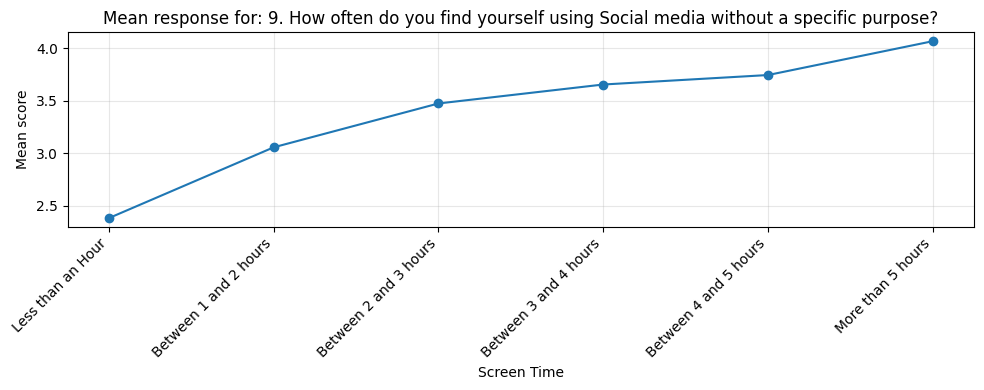

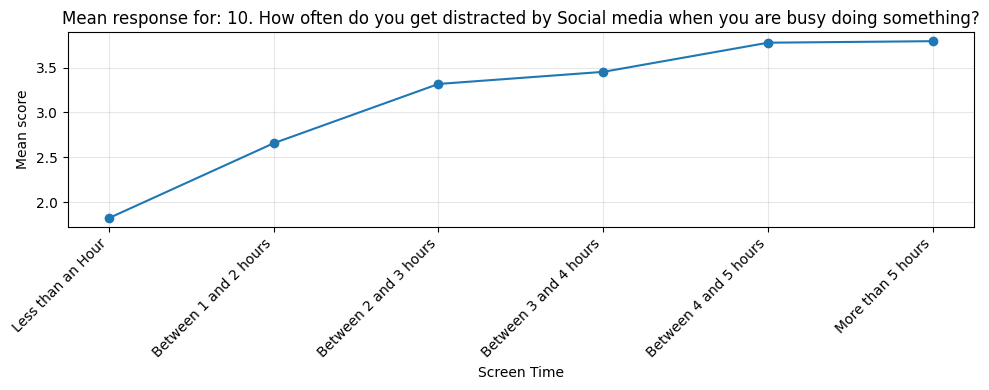

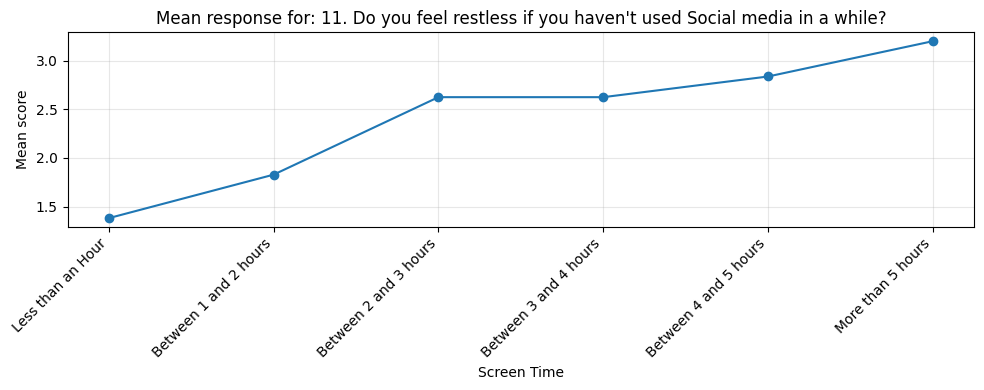

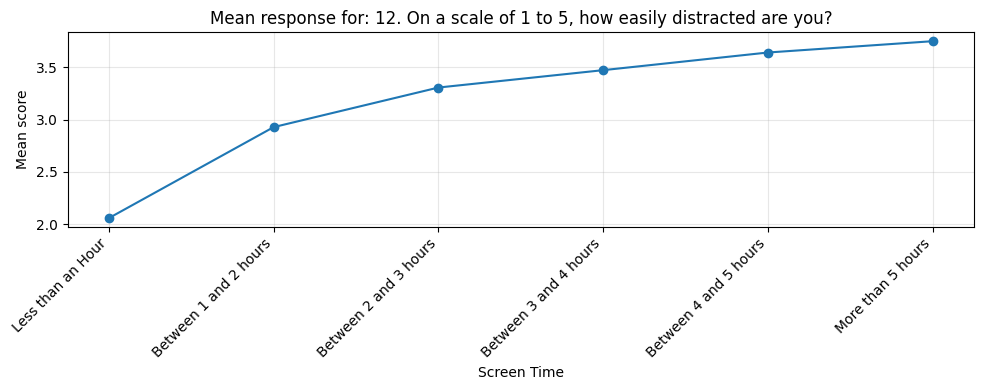

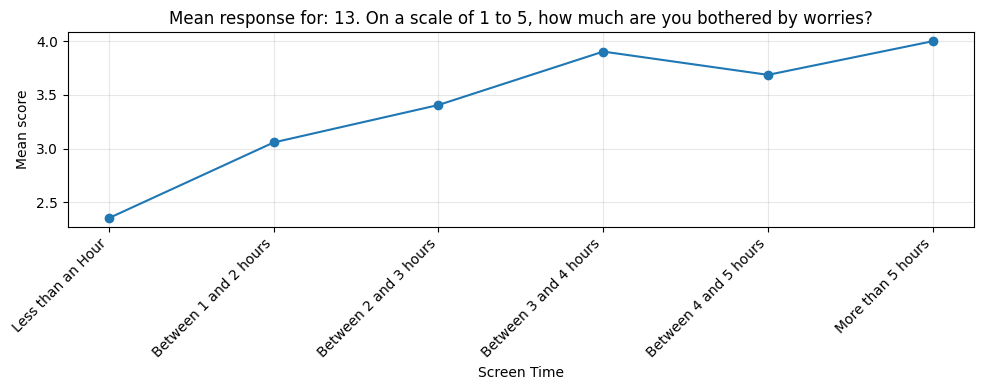

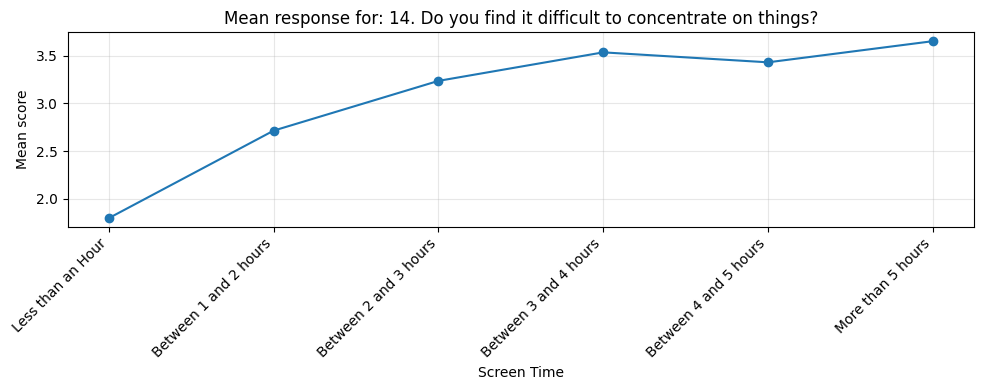

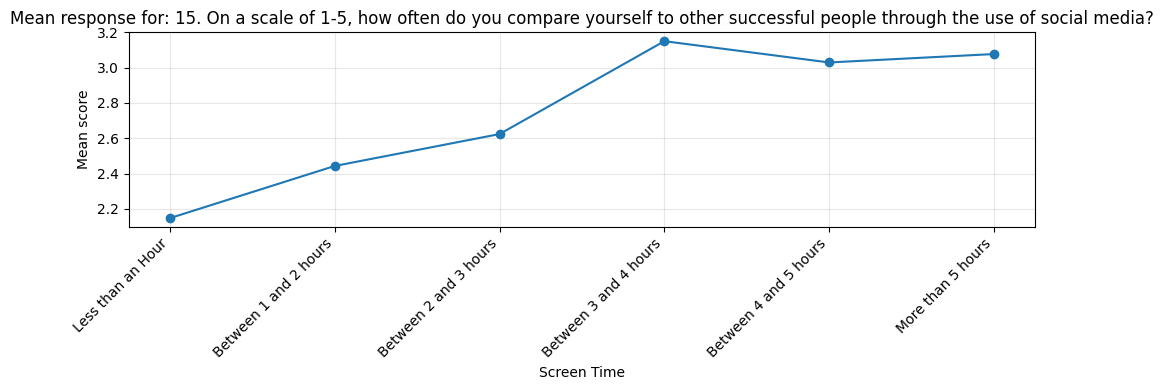

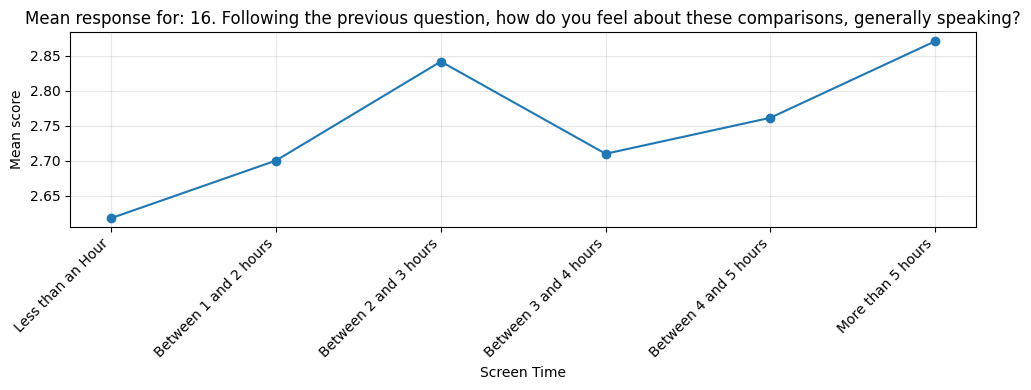

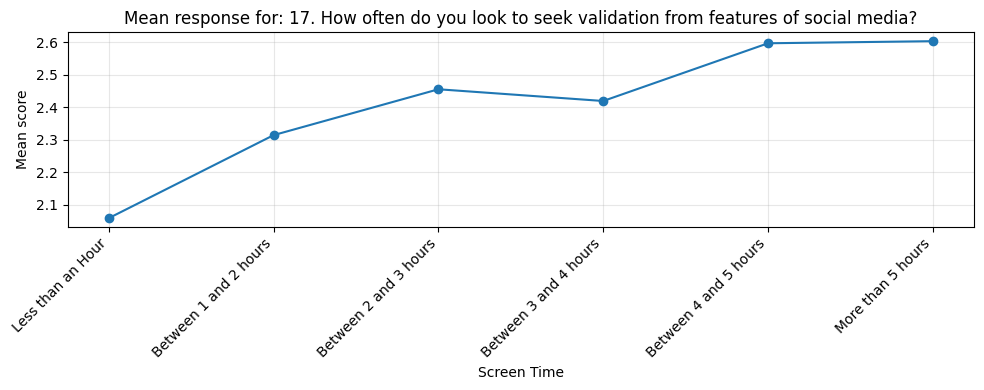

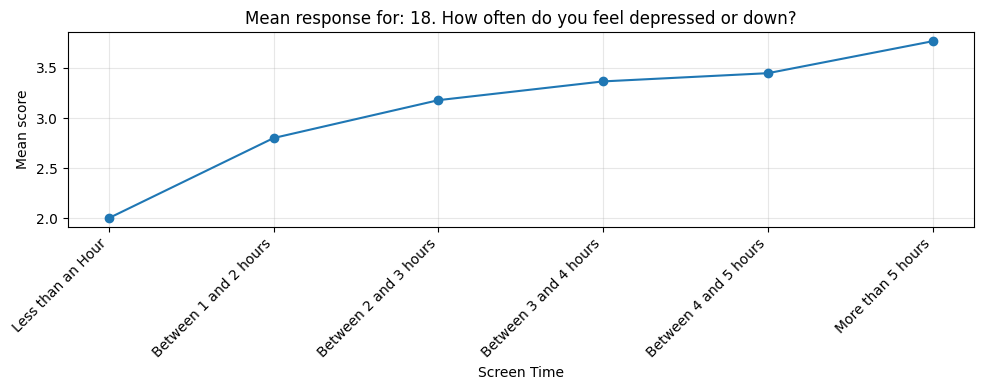

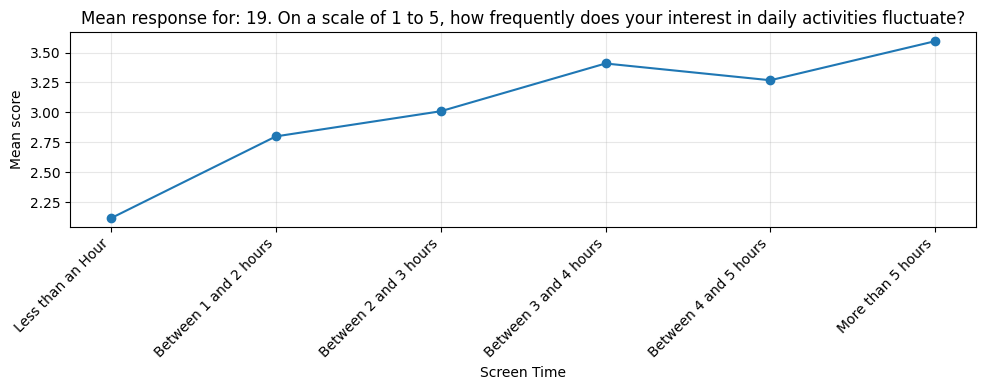

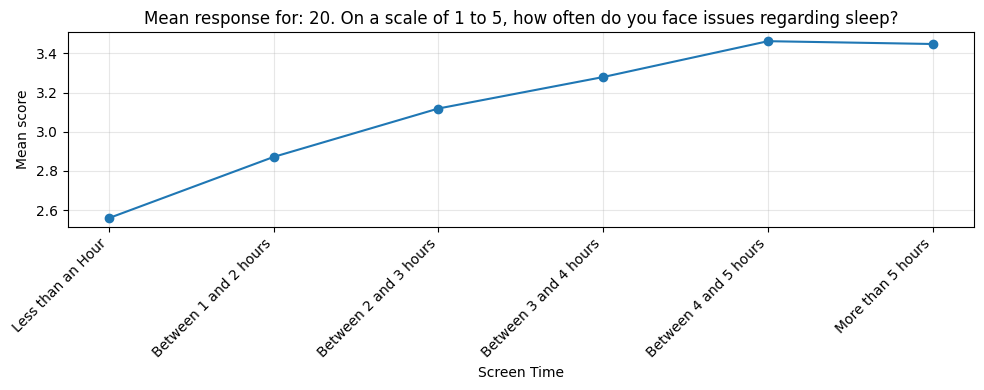

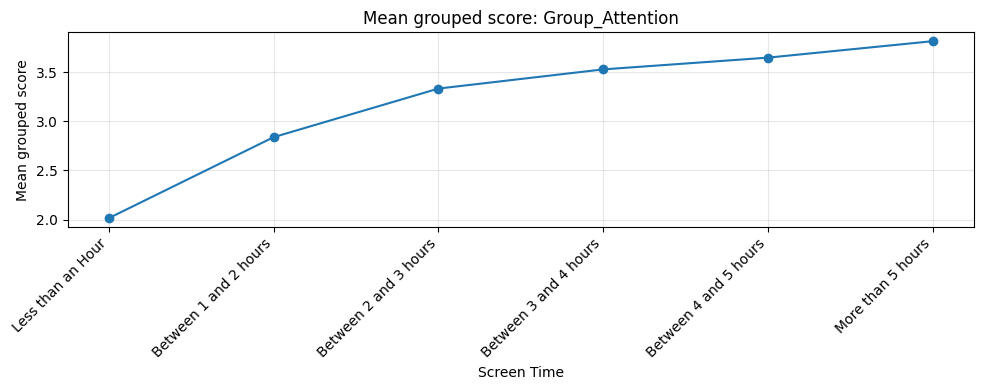

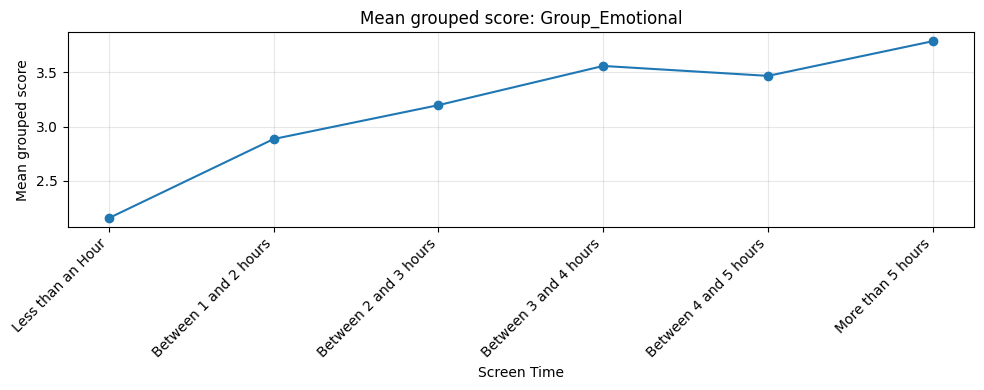

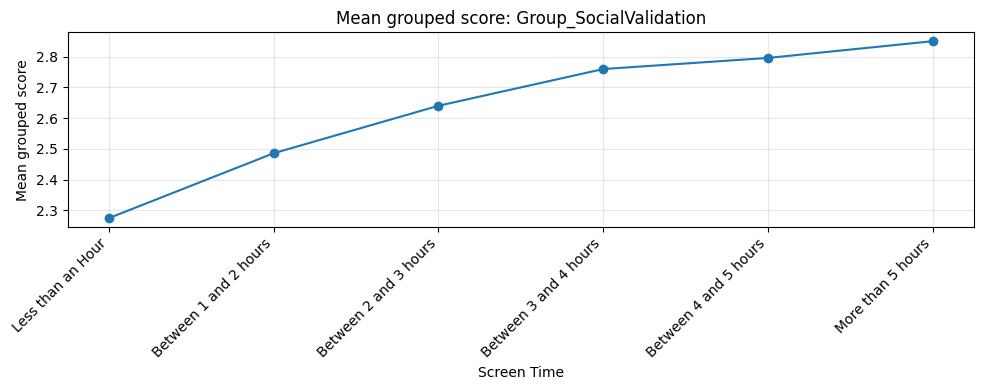

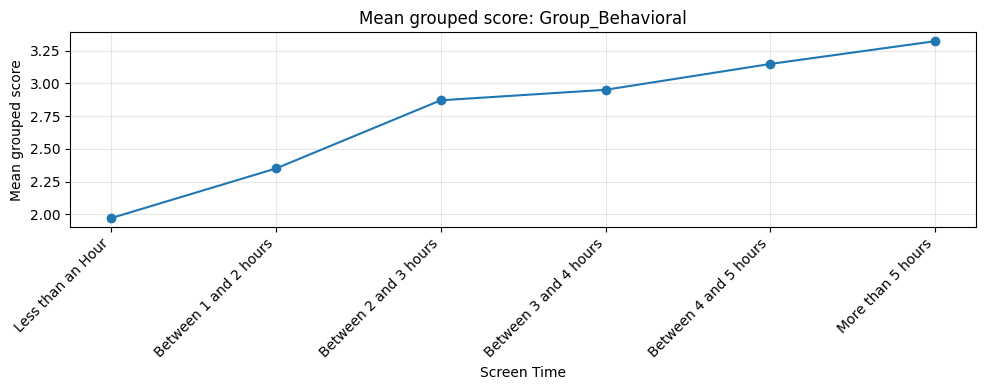

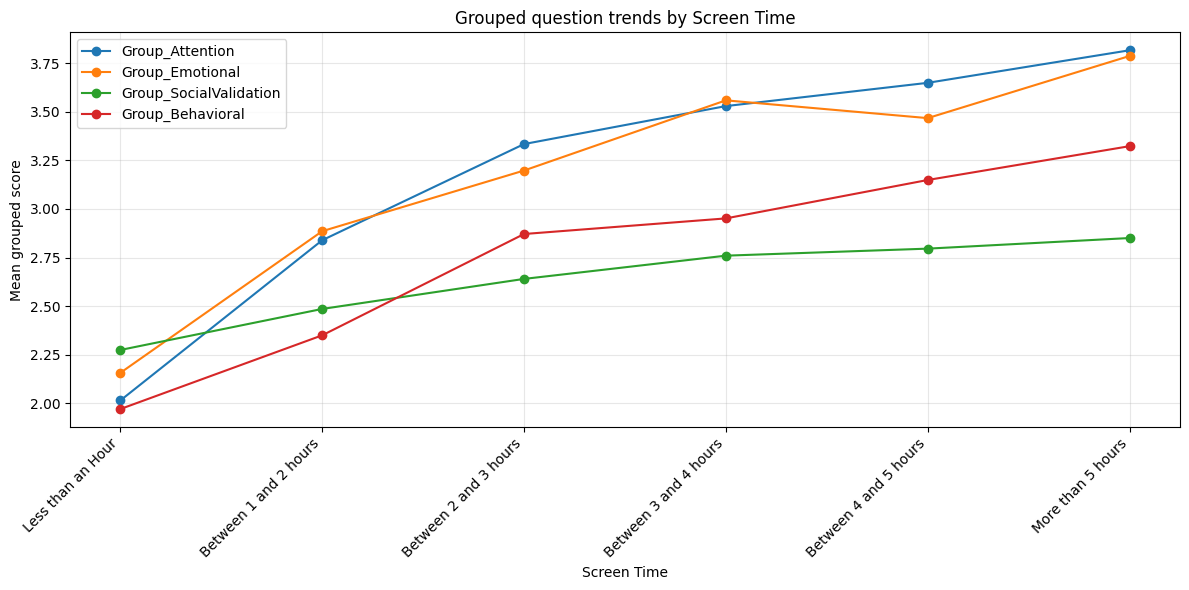

In [ ]:
import matplotlib.pyplot as plt

# Plot individual question trends by screen time using the mapping from cell 6
question_columns = list(questions.keys())
question_labels = questions

for col in question_columns:
    plt.figure(figsize=(10, 4))
    plt.plot(grouped['Screen Time'], grouped[col], marker='o', linestyle='-')
    plt.title(f"Mean response for: {question_labels[col]}")
    plt.xlabel('Screen Time')
    plt.ylabel('Mean score')
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot grouped question trends by screen time using the new mapped group names
grouped_columns = ['Group_Attention', 'Group_Emotional', 'Group_SocialValidation', 'Group_Behavioral']

for col in grouped_columns:
    plt.figure(figsize=(10, 4))
    plt.plot(grouped['Screen Time'], grouped[col], marker='o', linestyle='-')
    plt.title(f'Mean grouped score: {col}')
    plt.xlabel('Screen Time')
    plt.ylabel('Mean grouped score')
    plt.xticks(rotation=45, ha='right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Combined grouped overview
plt.figure(figsize=(12, 6))
for col in grouped_columns:
    plt.plot(grouped['Screen Time'], grouped[col], marker='o', linestyle='-', label=col)

plt.title('Grouped question trends by Screen Time')
plt.xlabel('Screen Time')
plt.ylabel('Mean grouped score')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Clustering

Following the grouping logic introduced before, we create a Digital Persona:
- The Doomscroller - people scoring higher than 4 in purposless and restless category, and spend more than 4 hours online
- The Insecure - users reporting above 4 when asked about comparing themselves or seeking validation online
- The Distracted - users scoring higher than 4 when asked about their sleep schedule and attention span
- The Anxious - people reporting higher than 3 score when asked about worries or depression
- The Professional - users reporting a score below 2 in questions regarding the distractions and restless feeling linked to social media use
- The Regular User - people that have a below 3 score regarding worries and spend 2-3 hours daily on social media
- Uncategorised - people not falling into any of the categories

This tab is supposed to offer a full on reader-driven story. The user have an option to choose the age group, marital status, occupation and the changing clusters when switching the categories. The popup windows allow them to read about a specific person represented by a dot, and also read about each of the Digital Personas when hovering over a cluster.

In [ ]:
def categorize_user(row):
    # 1. Off-grid (Absolute check)
    if row['6. Do you use social media?'] == 'No':
        return 'Off-grid'
    
    # Pre-calculate some common logic to keep it clean
    avg_time = row['8. What is the average time you spend on social media every day?']
    high_use = avg_time in ['More than 5 hours', 'Between 4 and 5 hours']
    mid_use = avg_time in ['Between 2 and 3 hours', 'Between 3 and 4 hours']
    
    # 2. The Doomscroller (Very specific behavior - High Priority)
    if high_use and row['9. How often do you find yourself using Social media without a specific purpose?'] >= 4:
        if row["11. Do you feel restless if you haven't used Social media in a while?"] >= 4:
            return 'The Doomscroller'
    
    # 3. The Anxious & Distracted (High impact on daily life)
    worries = row['13. On a scale of 1 to 5, how much are you bothered by worries?'] >= 4
    depressed = row['18. How often do you feel depressed or down?'] >= 4
    if worries and depressed:
        return 'The Anxious'

    distracted = row['12. On a scale of 1 to 5, how easily distracted are you?'] >= 4
    concentrate = row['14. Do you find it difficult to concentrate on things?'] >= 4
    if distracted and concentrate: 
        return 'The Distracted'

    # 4. The Insecure (Broadest negative category)
    validation = row['17. How often do you look to seek validation from features of social media?'] >= 4
    comparison = row['15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?'] >= 4
    if validation or comparison:
        return 'The Insecure'
        
    # 5. Professional (High discipline)
    focused = row['10. How often do you get distracted by Social media when you are busy doing something?'] <= 2
    not_restless = row["11. Do you feel restless if you haven't used Social media in a while?"] <= 2
    if focused and not_restless:
        return 'Professional'
        
    # 6. Regular User (Healthy, low-usage)
    low_time = avg_time in ['Less than an Hour', 'Between 1 and 2 hours']
    if low_time and row['13. On a scale of 1 to 5, how much are you bothered by worries?'] <= 3:
        return 'Regular User'

    # 7. NEW: The Casual Surfer (The "Catch-all" for the 3s and 4s)
    # If they've made it this far, they aren't 'Professional' but aren't 'Anxious'
    if mid_use or row['9. How often do you find yourself using Social media without a specific purpose?'] >= 3:
        return 'Casual Surfer'
        
    return 'Uncategorized'

df['Digital Persona'] = df.apply(categorize_user, axis=1)

NameError: name 'df' is not defined

In [ ]:
# How many users fall into each category?
persona_counts = df['Digital Persona'].value_counts()
print("\n--- Digital Persona Counts ---")  
print(persona_counts)


--- Digital Persona Counts ---
Digital Persona
The Anxious         151
Casual Surfer        70
Professional         68
The Distracted       62
The Insecure         60
The Doomscroller     47
Regular User         16
Uncategorized         4
Off-grid              3
Name: count, dtype: int64


In [ ]:
def export_updated_dataset(dataframe, filename='../data/smmh_with_personas.csv'):
    # Save to CSV
    dataframe.to_csv(filename, index=False)
    print(f"Dataset exported successfully to {filename}")
    # Print the first few rows of the updated dataframe
    print("\n--- Updated Dataset Preview ---")
    print(dataframe.head())

# Execute export
export_updated_dataset(df)

Dataset exported successfully to smmh_with_personas.csv

--- Updated Dataset Preview ---
            Timestamp  1. What is your age? 2. Gender 3. Relationship Status  \
0  4/18/2022 19:18:47                  21.0      Male      In a relationship   
1  4/18/2022 19:19:28                  21.0    Female                 Single   
2  4/18/2022 19:25:59                  21.0    Female                 Single   
3  4/18/2022 19:29:43                  21.0    Female                 Single   
4  4/18/2022 19:33:31                  21.0    Female                 Single   

  4. Occupation Status 5. What type of organizations are you affiliated with?  \
0   University Student                                         University       
1   University Student                                         University       
2   University Student                                         University       
3   University Student                                         University       
4   University Student   

In [ ]:
# All marital statues
relationship_status = df['3. Relationship Status'].unique()
print("\n--- Unique Relationship Statuses ---")
print(relationship_status)


--- Unique Relationship Statuses ---
<StringArray>
['In a relationship', 'Single', 'Married', 'Divorced']
Length: 4, dtype: str


In [ ]:
all_occupations = df['4. Occupation Status'].unique()
print("\n--- Unique Occupation Statuses ---")   
print(all_occupations)


--- Unique Occupation Statuses ---
<StringArray>
['University Student', 'School Student', 'Salaried Worker', 'Retired']
Length: 4, dtype: str


In [ ]:
all_related_companies = df['5. What type of organizations are you affiliated with?'].unique()
print("\n--- Unique Responses for Working in Social Media Related Company ---")
print(all_related_companies)


--- Unique Responses for Working in Social Media Related Company ---
<StringArray>
[                    'University',                        'Private',
                              nan,             'School, University',
                        'Company',                'School, Private',
            'University, Company',                      'Goverment',
               'Company, Private',                         'School',
 'University, Goverment, Private',   'University, Company, Private',
            'University, Private',                'University, N/A',
    'School, University, Private',          'University, Goverment',
 'University, Company, Goverment',                'School, Company',
                    'School, N/A']
Length: 19, dtype: str
